# Red Neuronal Siamesa para Reconocimiento Facial

**Dataset:** Olivetti Faces — 40 personas, 10 fotos por persona (400 total, 64x64 px)  TensorFlow / Keras

Flujo del notebook:
1. Explicacion conceptual
2. Preparacion del dataset
3. Generacion de triplets (ancla, positivo, negativo)
4. Arquitectura de la red siamesa
5. Triplet Loss y entrenamiento
6. Evaluacion con metricas
7. Pruebas con nuevos pares
8. Analisis y conclusiones

---

## 1.Red Neuronal Siamesa

Una red siamesa es una arquitectura que aprende una funcion de distancia en un
espacio latente para comparar pares de entradas. En lugar de clasificar en N clases
fijas, aprende a responder: *estas dos imagenes son de la misma persona?*


La Triplet Loss optimiza directamente el orden relativo de distancias:
fuerza que la ancla este mas cerca de su positivo que de cualquier negativo,
lo que produce espacios de embedding mas estructurados y mejor separacion.

Aplicaciones practicas:
- Reconocimiento facial (Face ID, FaceNet)
- Verificacion de firma
- Busqueda por similitud visual
- Few-shot learning

## 2. Importaciones y configuracion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("Configuracion lista.")

TensorFlow: 2.20.0
Configuracion lista.


## 3. Dataset Olivetti Faces

- 40 personas distintas, 10 fotos por persona = 400 imagenes
- Escala de grises, 64x64 px, valores ya normalizados en [0, 1]
- Variaciones de iluminacion, expresion facial y angulo entre fotos
- Multiples muestras por clase (necesarias para triplets positivos)
- Problema real de similitud facial


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Total imagenes : (400, 64, 64)
Personas       : 40 (ids 0..39)
Rango valores  : [0.00, 1.00] (ya normalizadas)


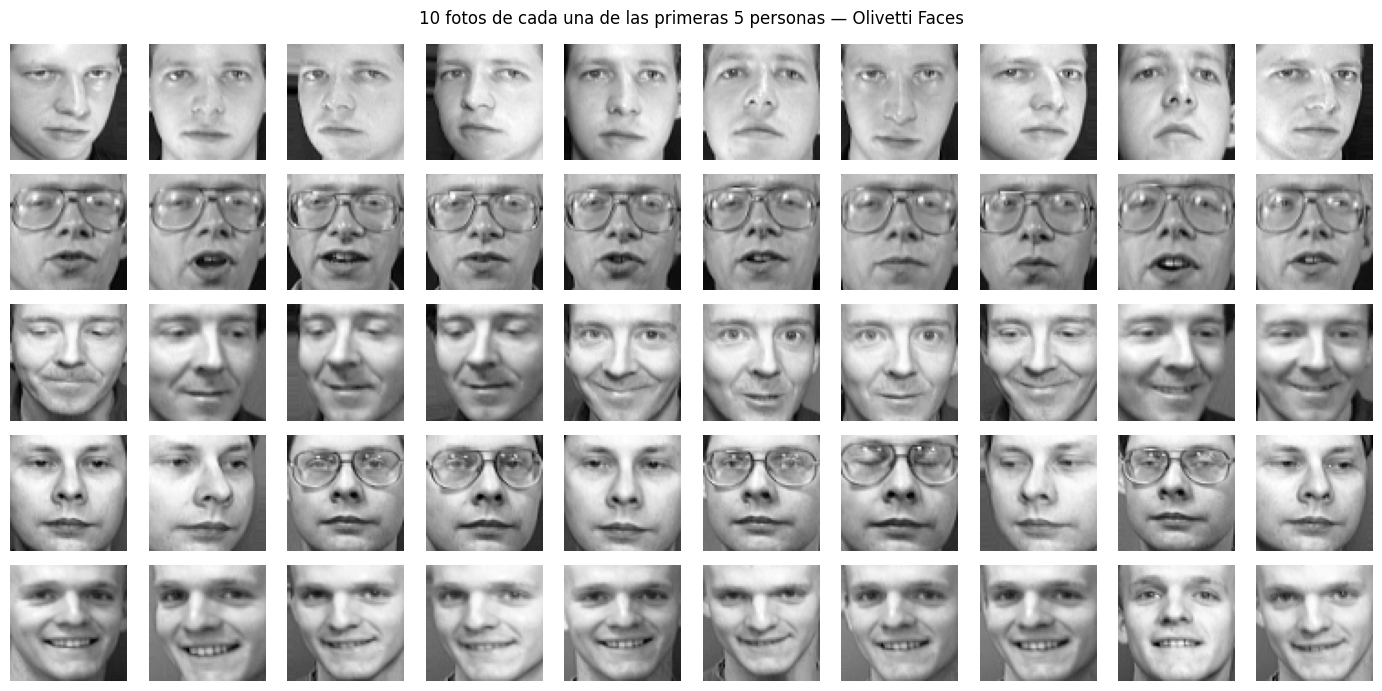

In [2]:
# Cargar dataset Olivetti Faces (~1.4 MB, descarga automatica)
datos = fetch_olivetti_faces(shuffle=True, random_state=SEED)
imagenes  = datos.images   # (400, 64, 64), valores en [0, 1]
etiquetas = datos.target   # (400,), ids 0..39

print(f"Total imagenes : {imagenes.shape}")
print(f"Personas       : {len(np.unique(etiquetas))} (ids {etiquetas.min()}..{etiquetas.max()})")
print(f"Rango valores  : [{imagenes.min():.2f}, {imagenes.max():.2f}] (ya normalizadas)")

# Agregar dimension de canal: (400, 64, 64) -> (400, 64, 64, 1)
imagenes = imagenes[..., np.newaxis].astype("float32")

# Visualizar 10 fotos de las primeras 5 personas
fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for persona in range(5):
    idx = np.where(etiquetas == persona)[0]
    for j, ax in enumerate(axes[persona]):
        ax.imshow(imagenes[idx[j], :, :, 0], cmap="gray")
        ax.axis("off")
    axes[persona, 0].set_ylabel(f"P{persona}", fontsize=9)
plt.suptitle("10 fotos de cada una de las primeras 5 personas — Olivetti Faces", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Division del dataset por persona

Es fundamental dividir el dataset a nivel de persona, no de imagen.
Si las mismas personas aparecen en train y test, el modelo podria memorizar
rostros especificos en lugar de aprender similitud generalizable.

- Train: 32 personas (320 imagenes)
- Test: 8 personas (80 imagenes)

In [3]:
# Dividir personas (no imagenes) para evitar data leakage
personas = np.unique(etiquetas)
personas_train, personas_test = train_test_split(
    personas, test_size=0.2, random_state=SEED
)

# Crear masks para separar imagenes por persona
mask_train = np.isin(etiquetas, personas_train)
mask_test  = np.isin(etiquetas, personas_test)

img_train, lbl_train = imagenes[mask_train], etiquetas[mask_train]
img_test,  lbl_test  = imagenes[mask_test],  etiquetas[mask_test]

print(f"Personas en train : {len(personas_train)} -> {img_train.shape[0]} imagenes")
print(f"Personas en test  : {len(personas_test)}  -> {img_test.shape[0]} imagenes")

Personas en train : 32 -> 320 imagenes
Personas en test  : 8  -> 80 imagenes


## 5. Generacion de Triplets

Cada triplet esta compuesto por tres imagenes:
- Ancla (A): imagen de referencia
- Positivo (P): otra imagen de la misma persona que A
- Negativo (N): imagen de una persona distinta a A

El objetivo del entrenamiento es que el modelo aprenda a cumplir:
```
distancia(A, P) + margin < distancia(A, N)
```
Es decir, la ancla debe estar mas cerca de su positivo que de cualquier negativo.

In [4]:
def generar_triplets(imagenes, etiquetas, n_triplets=300):
    """
    Genera triplets (ancla, positivo, negativo) para entrenamiento siames.

    Parametros:
        imagenes   : array de imagenes (N, H, W, C)
        etiquetas  : array de ids de persona (N,)
        n_triplets : cantidad de triplets a generar

    Retorna:
        anclas, positivos, negativos : tres arrays de imagenes emparejadas
    """
    clases = np.unique(etiquetas)
    anclas, positivos, negativos = [], [], []

    for _ in range(n_triplets):
        # Elegir la clase del ancla
        clase_ancla = np.random.choice(clases)
        idx_ancla = np.where(etiquetas == clase_ancla)[0]

        # Ancla y positivo: dos fotos DISTINTAS de la misma persona
        a, p = np.random.choice(idx_ancla, 2, replace=False)
        anclas.append(imagenes[a])
        positivos.append(imagenes[p])

        # Negativo: foto de una persona DISTINTA al ancla
        clase_neg = np.random.choice([c for c in clases if c != clase_ancla])
        n = np.random.choice(np.where(etiquetas == clase_neg)[0])
        negativos.append(imagenes[n])

    return (np.array(anclas, dtype="float32"),
            np.array(positivos, dtype="float32"),
            np.array(negativos, dtype="float32"))


# Generar triplets de entrenamiento y test
A_train, P_train, N_train = generar_triplets(img_train, lbl_train, n_triplets=1000)
A_test,  P_test,  N_test  = generar_triplets(img_test,  lbl_test,  n_triplets=300)

print(f"Triplets de entrenamiento : {A_train.shape[0]}")
print(f"Triplets de test          : {A_test.shape[0]}")
print(f"Forma de cada imagen      : {A_train.shape[1:]}")

Triplets de entrenamiento : 1000
Triplets de test          : 300
Forma de cada imagen      : (64, 64, 1)


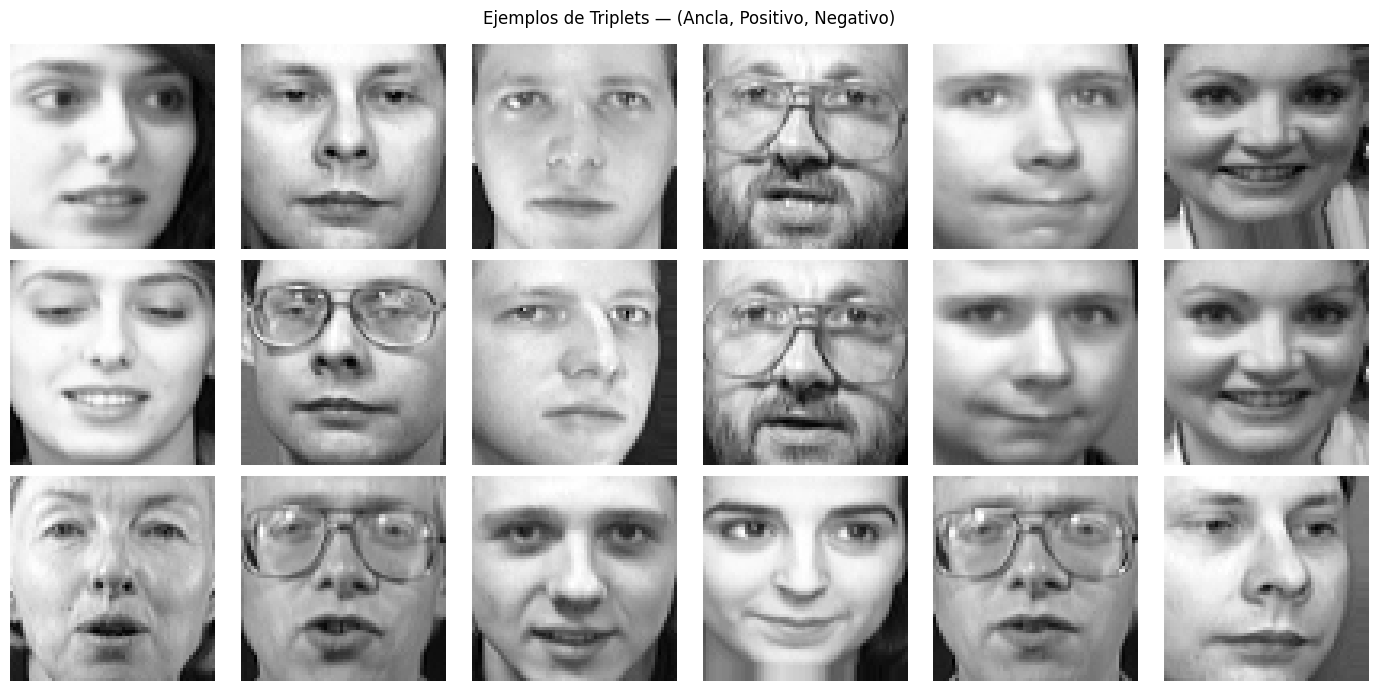

In [5]:
# Visualizar ejemplos de triplets
fig, axes = plt.subplots(3, 6, figsize=(14, 7))

etiquetas_filas = ["ANCLA", "POSITIVO\n(misma persona)", "NEGATIVO\n(diferente persona)"]
colores_filas   = ["black", "green", "red"]

for col in range(6):
    # Fila 0: ancla
    axes[0, col].imshow(A_train[col, :, :, 0], cmap="gray")
    axes[0, col].axis("off")
    # Fila 1: positivo (misma persona que ancla)
    axes[1, col].imshow(P_train[col, :, :, 0], cmap="gray")
    axes[1, col].axis("off")
    # Fila 2: negativo (persona distinta)
    axes[2, col].imshow(N_train[col, :, :, 0], cmap="gray")
    axes[2, col].axis("off")

# Etiquetas de fila
for fila, (etq, color) in enumerate(zip(etiquetas_filas, colores_filas)):
    axes[fila, 0].set_ylabel(etq, fontsize=9, color=color, fontweight="bold")

plt.suptitle("Ejemplos de Triplets — (Ancla, Positivo, Negativo)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Arquitectura de la Red Siamesa

**Componentes:**

1. subred de embedding (compartida):transforma cada imagen en un vector de
   128 dimensiones normalizado en L2 (sobre la esfera unitaria).
2. Capa de distancia euclidiana: calcula `d = sqrt(sum((A-B)^2))`.
3. Tres ramas con pesos compartidos: la misma subred procesa ancla, positivo y negativo.
4. Salida: vector `[d_pos, d_neg]` — las dos distancias que la Triplet Loss necesita.

In [6]:
def construir_subred(input_shape=(64, 64, 1), embedding_dim=128):
    """
    Subred de embedding compartida entre las tres ramas de la red siamesa.
    Convierte una imagen en un vector de embedding_dim dimensiones normalizado en L2.
    """
    entradas = keras.Input(shape=input_shape)

    # Bloque 1: caracteristicas de bajo nivel (bordes, texturas)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(entradas)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)    # 64x64 -> 32x32

    # Bloque 2: patrones de nivel medio (partes del rostro)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)    # 32x32 -> 16x16

    # Bloque 3: representaciones de alto nivel (identidad facial)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)  # 16x16 -> vector de 128

    # Proyectar al espacio de embedding
    x = layers.Dense(embedding_dim)(x)

    # Normalizar L2: proyectar sobre la esfera unitaria
    # Esto garantiza que las distancias euclidianas esten acotadas en [0, 2]
    x = layers.UnitNormalization(axis=1)(x)

    return keras.Model(inputs=entradas, outputs=x, name="subred_embedding")


subred = construir_subred()
subred.summary()

Model: "subred_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unit_normalization              │ (None, 128)            │             0 │
│ (UnitNormalization)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,080 (430.00 KB)

 Trainable params: 109,632 (428.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
class CapaDistanciaEuclidiana(layers.Layer):
    """
    Capa personalizada que calcula la distancia euclidiana (L2)
    entre dos vectores de embedding.
    Formula: d = sqrt( sum( (emb_A - emb_B)^2 ) + epsilon )
    El epsilon evita gradientes indefinidos cuando la distancia es 0.
    """
    def call(self, embeddings):
        emb_a, emb_b = embeddings
        diferencia = emb_a - emb_b
        distancia  = tf.sqrt(
            tf.reduce_sum(tf.square(diferencia), axis=1, keepdims=True) + 1e-6
        )
        return distancia


def construir_siamesa_triplet(subred, input_shape=(64, 64, 1)):
    """
    Red siamesa para Triplet Loss.
    Tres entradas (ancla, positivo, negativo) con pesos compartidos.
    Salida: [d_ancla_positivo, d_ancla_negativo]
    """
    entrada_a = keras.Input(shape=input_shape, name="ancla")
    entrada_p = keras.Input(shape=input_shape, name="positivo")
    entrada_n = keras.Input(shape=input_shape, name="negativo")

    # Las tres ramas usan la MISMA subred (pesos compartidos)
    emb_a = subred(entrada_a)
    emb_p = subred(entrada_p)
    emb_n = subred(entrada_n)

    # Distancia ancla-positivo (debe ser pequena)
    d_pos = CapaDistanciaEuclidiana()([emb_a, emb_p])
    # Distancia ancla-negativo (debe ser grande)
    d_neg = CapaDistanciaEuclidiana()([emb_a, emb_n])

    # Concatenar distancias: la Triplet Loss necesita ambas
    salida = layers.Concatenate(name="distancias")([d_pos, d_neg])

    return keras.Model(
        inputs=[entrada_a, entrada_p, entrada_n],
        outputs=salida,
        name="Red_Siamesa_Triplet"
    )


modelo_triplet = construir_siamesa_triplet(subred)
modelo_triplet.summary()

Model: "Red_Siamesa_Triplet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ancla (InputLayer)  │ (None, 64, 64, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positivo            │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negativo            │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subred_embedding    │ (None, 128)       │    110,080 │ ancla[0][0],      │
│ (Functional)        │                   │            │ positivo[0][0],   │
│                     │                   │            │ negativo[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_distancia_euc… │ (None, 1)         │          0 │ subred_embedding… │
│ (CapaDistanciaEucl… │                   │            │ subred_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_distancia_euc… │ (None, 1)         │          0 │ subred_embedding… │
│ (CapaDistanciaEucl… │                   │            │ subred_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distancias          │ (None, 2)         │          0 │ capa_distancia_e… │
│ (Concatenate)       │                   │            │ capa_distancia_e… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110,080 (430.00 KB)

 Trainable params: 109,632 (428.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 7. Triplet Loss entrenamiento

Triplet Loss:
```
L = max(0, d(A, P) - d(A, N) + margin)
```

- Si `d(A,N) > d(A,P) + margin`: loss = 0 (triplet ya satisfecho)
- Si `d(A,N) <= d(A,P) + margin`: loss > 0 (el modelo necesita mejorar)

El `margin` (margen) define la separacion minima que debe existir entre
la distancia positiva y la negativa. Un margen de 0.5 es apropiado
cuando los embeddings estan normalizados en L2 (distancias acotadas en [0, 2]).

In [8]:
def triplet_loss(margin=0.5):
    """
    Triplet Loss con margen configurable.

    Formula: L = mean( max(0, d_pos - d_neg + margin) )
    donde:
        d_pos = distancia euclidiana entre ancla y positivo
        d_neg = distancia euclidiana entre ancla y negativo
        margin = separacion minima requerida entre d_pos y d_neg

    El modelo aprende a empujar: d_pos + margin < d_neg
    """
    def loss(y_true, y_pred):
        # y_pred es el vector concatenado [d_pos, d_neg] de shape (batch, 2)
        d_pos = y_pred[:, 0]   # distancia ancla-positivo
        d_neg = y_pred[:, 1]   # distancia ancla-negativo
        # Penalizar cuando d_pos no es menor que d_neg por al menos margin
        return tf.reduce_mean(tf.maximum(0.0, d_pos - d_neg + margin))
    return loss


MARGIN = 0.5

modelo_triplet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=triplet_loss(margin=MARGIN)
)

print(f"Modelo compilado con Triplet Loss (margin={MARGIN}).")

Modelo compilado con Triplet Loss (margin=0.5).


In [9]:
# La Triplet Loss no necesita etiquetas reales — el triplet en si define el objetivo
# Se pasa un vector de ceros como y_dummy (requerido por la API de Keras)
y_dummy_train = np.zeros(len(A_train), dtype="float32")
y_dummy_test  = np.zeros(len(A_test),  dtype="float32")

# Callbacks: EarlyStopping + ReduceLROnPlateau
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, verbose=1
    )
]

print("Entrenando Red Siamesa con Triplet Loss...")
historia = modelo_triplet.fit(
    [A_train, P_train, N_train], y_dummy_train,
    validation_data=([A_test, P_test, N_test], y_dummy_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print("Entrenamiento completado.")

Entrenando Red Siamesa con Triplet Loss...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - loss: 0.1278 - val_loss: 0.4948 - learning_rate: 1.0000e-04
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 0.0718 - val_loss: 0.4869 - learning_rate: 1.0000e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0464 - val_loss: 0.4664 - learning_rate: 1.0000e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - loss: 0.0302 - val_loss: 0.4305 - learning_rate: 1.0000e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.0244 - val_loss: 0.3844 - learning_rate: 1.0000e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.0172 - val_loss: 0.3097 - learning_rate: 1.0000e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - loss: 0.0129 - val_loss: 0.2118 - learning_rate: 1.0000e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 985ms/step - loss: 0.0110 - val_loss: 0.1385 - learning_rate: 1.0000e-04
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 988ms/step - los

## 8. Evaluacion del modelo

La metrica principal para modelos con Triplet Loss es el
Triplet Accuracy: fraccion de triplets donde la ancla esta mas cerca
del positivo que del negativo, es decir donde `d_pos < d_neg`.

Adicionalmente se usa un umbral de decision para clasificacion binaria
(mismo/diferente) y se reportan las metricas de clasificacion estandar.

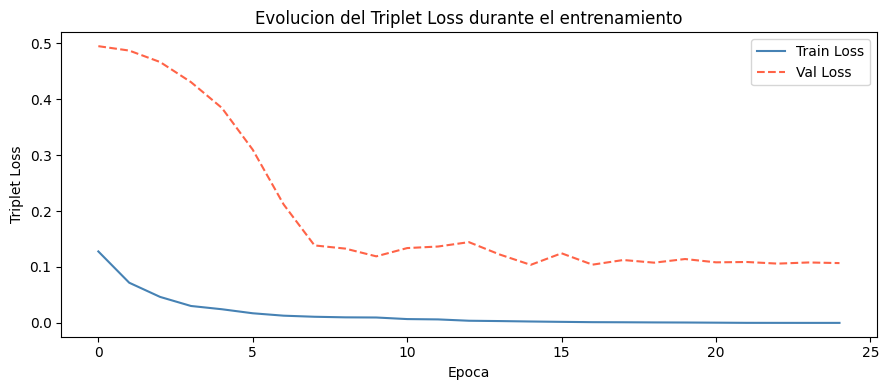

In [10]:
# Curva de entrenamiento
plt.figure(figsize=(9, 4))
plt.plot(historia.history["loss"],     label="Train Loss", color="steelblue")
plt.plot(historia.history["val_loss"], label="Val Loss",   color="tomato", linestyle="--")
plt.title("Evolucion del Triplet Loss durante el entrenamiento")
plt.xlabel("Epoca"); plt.ylabel("Triplet Loss")
plt.legend()
plt.tight_layout()
plt.show()

Triplet Accuracy : 0.9500
  d_pos media    : 0.7222 +/- 0.2329
  d_neg media    : 1.2918 +/- 0.2505
  Margen medio   : 0.5696


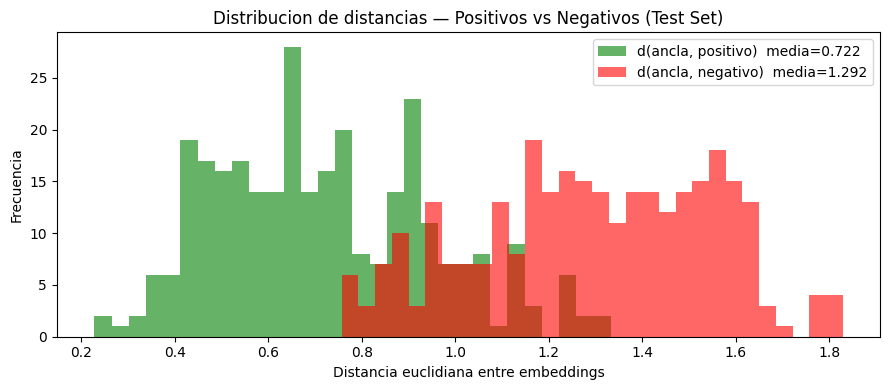

In [11]:
# Predecir distancias en el test set
pred_test = modelo_triplet.predict([A_test, P_test, N_test], verbose=0)
d_pos_test = pred_test[:, 0]   # distancia ancla-positivo
d_neg_test = pred_test[:, 1]   # distancia ancla-negativo

# Triplet Accuracy: fraccion donde d_pos < d_neg (objetivo cumplido)
triplet_acc = np.mean(d_pos_test < d_neg_test)
print(f"Triplet Accuracy : {triplet_acc:.4f}")
print(f"  d_pos media    : {d_pos_test.mean():.4f} +/- {d_pos_test.std():.4f}")
print(f"  d_neg media    : {d_neg_test.mean():.4f} +/- {d_neg_test.std():.4f}")
print(f"  Margen medio   : {(d_neg_test - d_pos_test).mean():.4f}")

# Visualizar distribucion de distancias
plt.figure(figsize=(9, 4))
plt.hist(d_pos_test, bins=30, alpha=0.6, color="green",
         label=f"d(ancla, positivo)  media={d_pos_test.mean():.3f}")
plt.hist(d_neg_test, bins=30, alpha=0.6, color="red",
         label=f"d(ancla, negativo)  media={d_neg_test.mean():.3f}")
plt.xlabel("Distancia euclidiana entre embeddings")
plt.ylabel("Frecuencia")
plt.title("Distribucion de distancias — Positivos vs Negativos (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

Umbral optimo  : 0.9393
Accuracy optimo: 0.8583


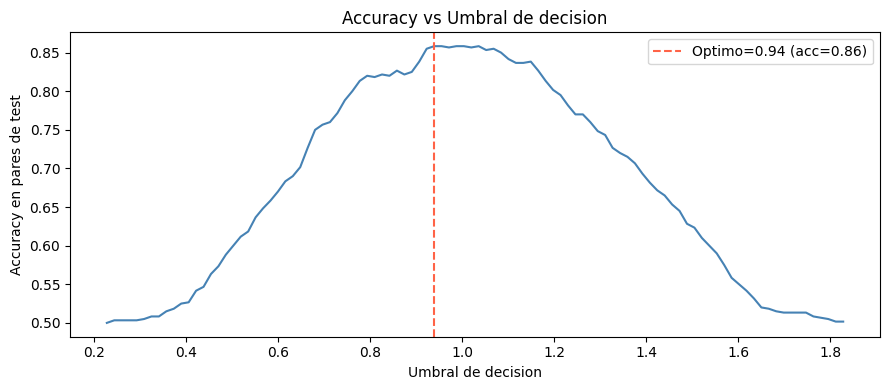

In [12]:
# Para clasificacion binaria (mismo/diferente) se necesita un umbral
# Se construyen pares positivos y negativos a partir de los triplets de test

# Par A-P (positivo, misma persona) y par A-N (negativo, diferente persona)
distancias_pares = np.concatenate([d_pos_test, d_neg_test])
etiquetas_pares  = np.concatenate([
    np.zeros(len(d_pos_test)),   # 0 = mismo
    np.ones(len(d_neg_test))     # 1 = diferente
])

# Barrer umbrales y calcular accuracy para cada uno
umbrales   = np.linspace(distancias_pares.min(), distancias_pares.max(), 100)
accuracies = []
for t in umbrales:
    y_pred_t = (distancias_pares >= t).astype(int)
    acc_t = np.mean(y_pred_t == etiquetas_pares)
    accuracies.append(acc_t)

# Umbral optimo
idx_opt   = np.argmax(accuracies)
THRESHOLD = umbrales[idx_opt]
ACC_OPT   = accuracies[idx_opt]

print(f"Umbral optimo  : {THRESHOLD:.4f}")
print(f"Accuracy optimo: {ACC_OPT:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(umbrales, accuracies, color="steelblue")
plt.axvline(THRESHOLD, color="tomato", linestyle="--",
            label=f"Optimo={THRESHOLD:.2f} (acc={ACC_OPT:.2f})")
plt.xlabel("Umbral de decision")
plt.ylabel("Accuracy en pares de test")
plt.title("Accuracy vs Umbral de decision")
plt.legend()
plt.tight_layout()
plt.show()

Metricas — Test Set
Triplet Accuracy (d_pos < d_neg) : 0.9500
Accuracy binaria (con umbral)    : 0.8583
Precision                        : 0.8349
Recall                           : 0.8933
F1 Score                         : 0.8631
AUC-ROC                          : 0.9445


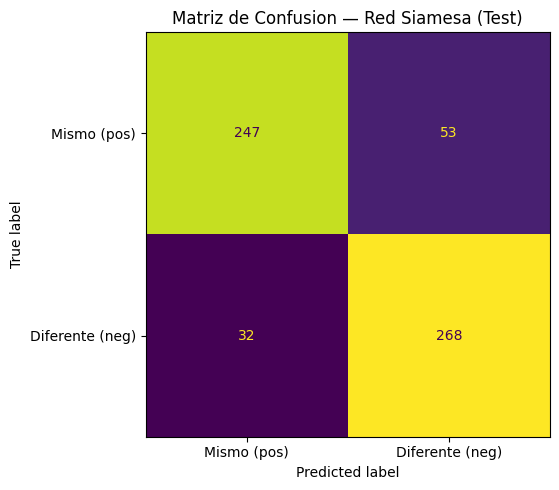

In [13]:
# Metricas de clasificacion binaria con el umbral optimo
y_pred_bin = (distancias_pares >= THRESHOLD).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc  = accuracy_score(etiquetas_pares, y_pred_bin)
prec = precision_score(etiquetas_pares, y_pred_bin, zero_division=0)
rec  = recall_score(etiquetas_pares, y_pred_bin, zero_division=0)
f1   = f1_score(etiquetas_pares, y_pred_bin, zero_division=0)
auc  = roc_auc_score(etiquetas_pares, distancias_pares)

print("=" * 48)
print("Metricas — Test Set")
print("=" * 48)
print(f"Triplet Accuracy (d_pos < d_neg) : {triplet_acc:.4f}")
print(f"Accuracy binaria (con umbral)    : {acc:.4f}")
print(f"Precision                        : {prec:.4f}")
print(f"Recall                           : {rec:.4f}")
print(f"F1 Score                         : {f1:.4f}")
print(f"AUC-ROC                          : {auc:.4f}")
print("=" * 48)

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(etiquetas_pares, y_pred_bin)
disp = ConfusionMatrixDisplay(cm, display_labels=["Mismo (pos)", "Diferente (neg)"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusion — Red Siamesa (Test)")
plt.tight_layout()
plt.show()

## 9. Pruebas con nuevos pares

Se visualizan triplets del test set con las distancias predichas y la decision
del modelo. Se muestra si el modelo coloca correctamente al positivo mas cerca
que al negativo.

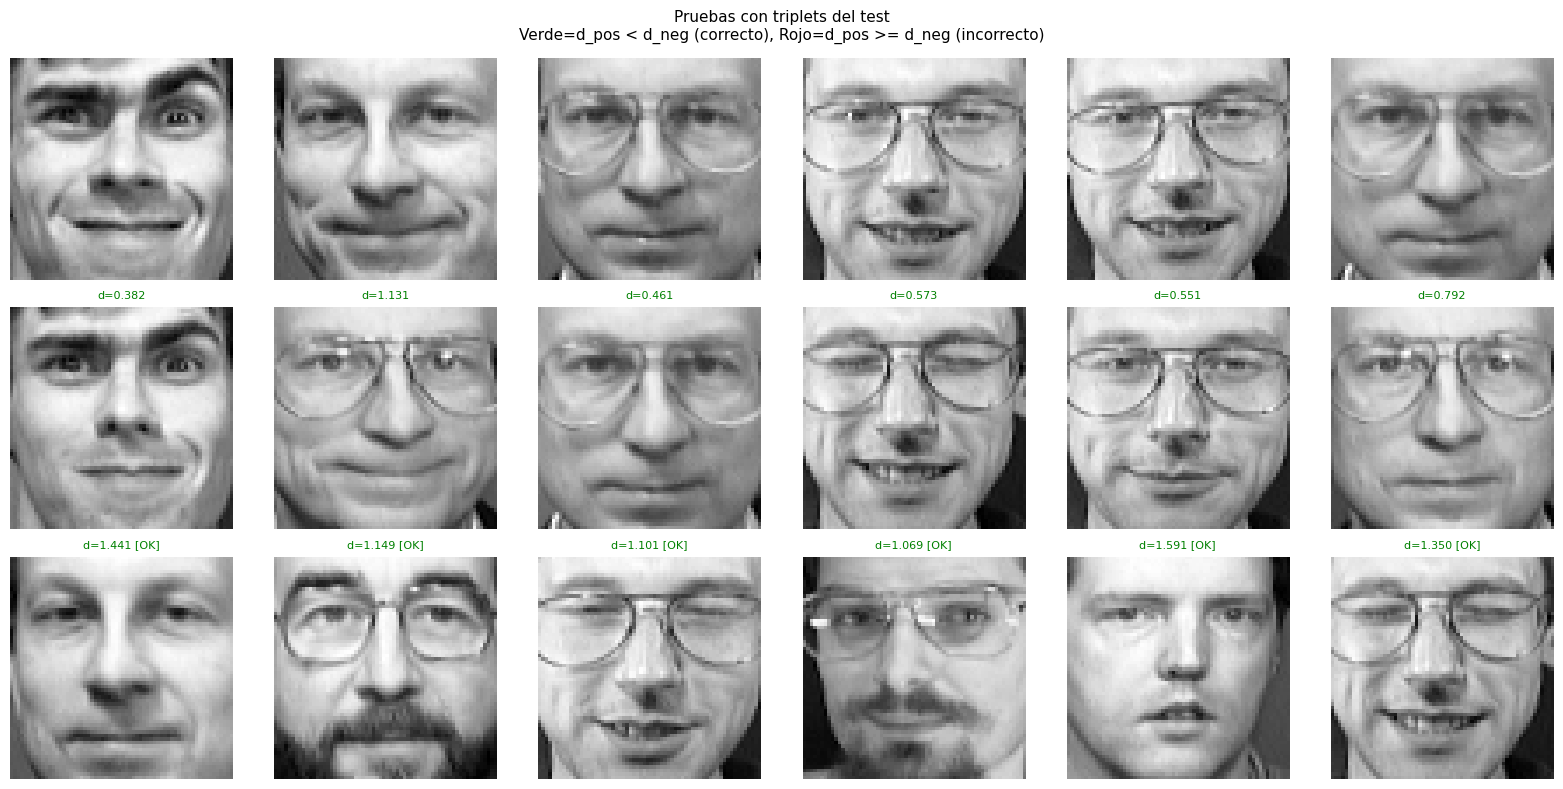

In [14]:
np.random.seed(SEED)
indices = np.random.choice(len(A_test), 6, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
etiq_filas = ["ANCLA", "POSITIVO", "NEGATIVO"]

for col, idx in enumerate(indices):
    dp = d_pos_test[idx]   # distancia ancla-positivo
    dn = d_neg_test[idx]   # distancia ancla-negativo
    correcto = dp < dn     # correcto si positivo esta mas cerca
    color = "green" if correcto else "red"

    # Fila 0: ancla
    axes[0, col].imshow(A_test[idx, :, :, 0], cmap="gray")
    axes[0, col].axis("off")

    # Fila 1: positivo con distancia
    axes[1, col].imshow(P_test[idx, :, :, 0], cmap="gray")
    axes[1, col].set_title(f"d={dp:.3f}", fontsize=8, color="green")
    axes[1, col].axis("off")

    # Fila 2: negativo con distancia y veredicto
    axes[2, col].imshow(N_test[idx, :, :, 0], cmap="gray")
    veredicto = "OK" if correcto else "FALLO"
    axes[2, col].set_title(f"d={dn:.3f} [{veredicto}]", fontsize=8, color=color)
    axes[2, col].axis("off")

for fila, etq in enumerate(etiq_filas):
    axes[fila, 0].set_ylabel(etq, fontsize=9, fontweight="bold")

plt.suptitle("Pruebas con triplets del test\n"
             "Verde=d_pos < d_neg (correcto), Rojo=d_pos >= d_neg (incorrecto)",
             fontsize=11)
plt.tight_layout()
plt.show()

## 10. Analisis del  embedding y tipos de error


Triplets correctos  : 285 / 300
Triplets incorrectos: 15 / 300

En errores:
  d_pos media : 1.1231
  d_neg media : 0.9363
  (d_pos y d_neg estan muy cerca del umbral -> casos ambiguos)


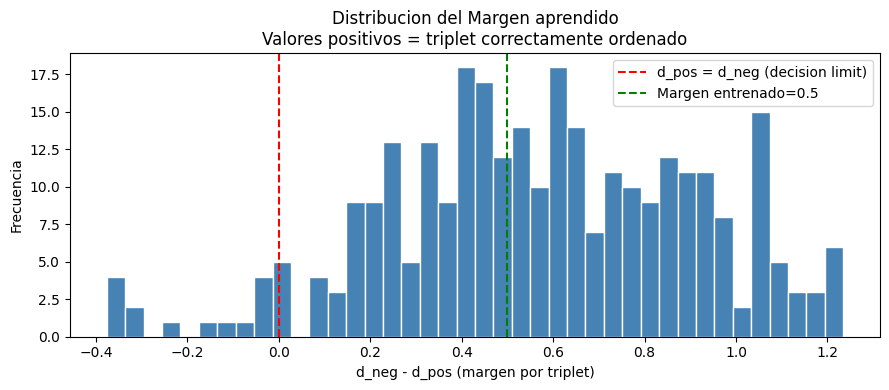

In [15]:
# Analisis de errores: triplets donde d_pos >= d_neg
errores = d_pos_test >= d_neg_test
n_errores = errores.sum()
print(f"Triplets correctos  : {(~errores).sum()} / {len(errores)}")
print(f"Triplets incorrectos: {n_errores} / {len(errores)}")
print()

# Distancias promedio en errores vs aciertos
if n_errores > 0:
    print(f"En errores:")
    print(f"  d_pos media : {d_pos_test[errores].mean():.4f}")
    print(f"  d_neg media : {d_neg_test[errores].mean():.4f}")
    print(f"  (d_pos y d_neg estan muy cerca del umbral -> casos ambiguos)")

# Distribucion del margen aprendido (d_neg - d_pos)
margenes = d_neg_test - d_pos_test
plt.figure(figsize=(9, 4))
plt.hist(margenes, bins=40, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", label="d_pos = d_neg (decision limit)")
plt.axvline(MARGIN, color="green", linestyle="--", label=f"Margen entrenado={MARGIN}")
plt.xlabel("d_neg - d_pos (margen por triplet)")
plt.ylabel("Frecuencia")
plt.title("Distribucion del Margen aprendido\n"
          "Valores positivos = triplet correctamente ordenado")
plt.legend()
plt.tight_layout()
plt.show()

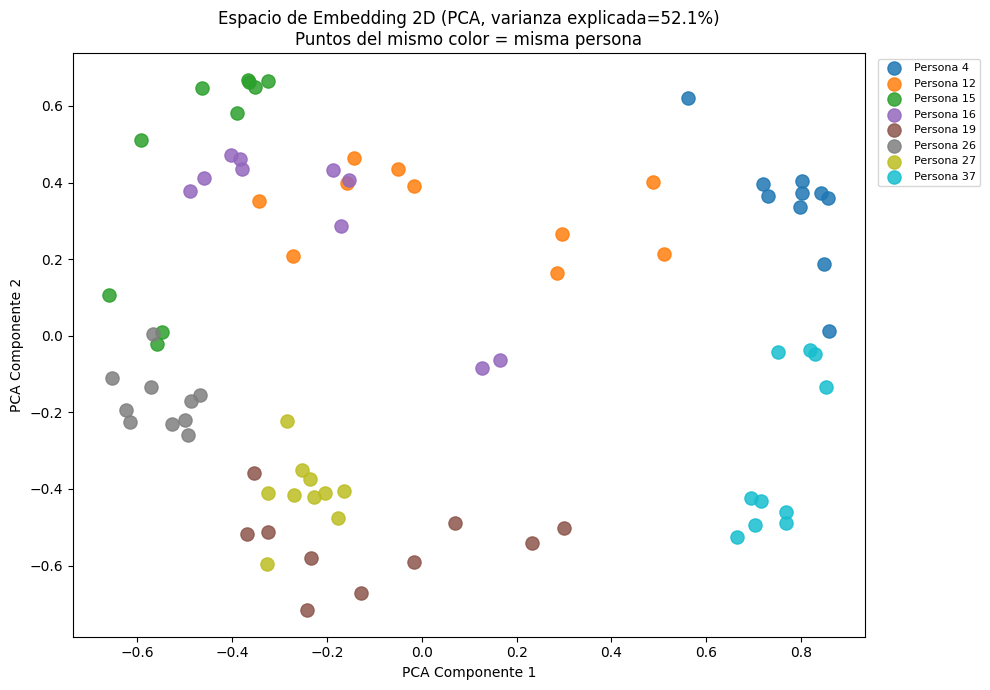

In [16]:
# Visualizar espacio de embedding 2D con PCA
embeddings_test = subred.predict(img_test, verbose=0)

# Reducir a 2D
pca = PCA(n_components=2, random_state=SEED)
emb_2d = pca.fit_transform(embeddings_test)
var_explicada = pca.explained_variance_ratio_.sum()

# Visualizar las 8 personas del test con colores distintos
personas_test_unicas = np.unique(lbl_test)
colores = plt.cm.tab10(np.linspace(0, 1, len(personas_test_unicas)))

plt.figure(figsize=(10, 7))
for persona, color in zip(personas_test_unicas, colores):
    mask = lbl_test == persona
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                color=color, label=f"Persona {persona}", s=90, alpha=0.85)

plt.xlabel(f"PCA Componente 1")
plt.ylabel(f"PCA Componente 2")
plt.title(f"Espacio de Embedding 2D (PCA, varianza explicada={var_explicada:.1%})\n"
          "Puntos del mismo color = misma persona")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## 11. Conclusiones

1. La Triplet Loss produce un espacio de embedding mas estructurado que la Contrastive Loss
Al optimizar directamente el orden relativo de distancias (d_pos + margin < d_neg),

2. la Triplet Loss crea clusters mas compactos por persona y mayor separacion entre personas
distintas. Esto es visible en el grafico de distribucion de margenes y en la visualizacion PCA.

3. El Triplet Accuracy es la metrica natural para este tipo de modelo
A diferencia de accuracy de clasificacion convencional, el Triplet Accuracy
mide directamente si el modelo aprende el orden de similitud correcto, sin depender
de un umbral

4. El umbral de decision es un hiperparametro critico en produccion  
Un umbral bajo reduce falsos negativos (no rechazar al usuario legítimo) pero
aumenta falsos positivos (aceptar impostores). En sistemas de seguridad el umbral
se ajusta segun el costo relativo de cada tipo de error.
